In [1]:
# Import libraries
import pandas as pd
import numpy as np
import datetime
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns
import scipy.stats as stats
from scipy.optimize import minimize
import warnings
warnings.filterwarnings('ignore')

In [ ]:
## SCARICAMENTO DATI

start = datetime.datetime(2016, 3, 31)
end   = datetime.datetime(2026, 3, 31)
tickers = ['XLF', 'XLK', 'XLV', 'XLE', 'XLI', 'XLY', '^GSPC']

data = yf.download(tickers, start=start, end=end, auto_adjust=True)
prezzi = data['Close'].rename(columns={'^GSPC': 'SP500'})

# Rendimenti logaritmici giornalieri
log_returns = np.log(prezzi / prezzi.shift(1)).dropna()

# Rendimenti logaritmici mensili
log_returns_monthly = log_returns.resample('ME').sum()

etfs = ['XLF', 'XLK', 'XLV', 'XLE', 'XLI', 'XLY']

[*********************100%***********************]  7 of 7 completed

Dati caricati. Shape giornaliero: (2513, 7)
Shape mensile: (120, 7)


---
# PUNTO 3 – CAPM e Fattori Fama-French

--- Beta di ciascun ETF rispetto all'S&P 500 ---
       Beta
XLF  1.0572
XLK  1.1376
XLV  0.6984
XLE  1.1074
XLI  1.1198
XLY  1.1871


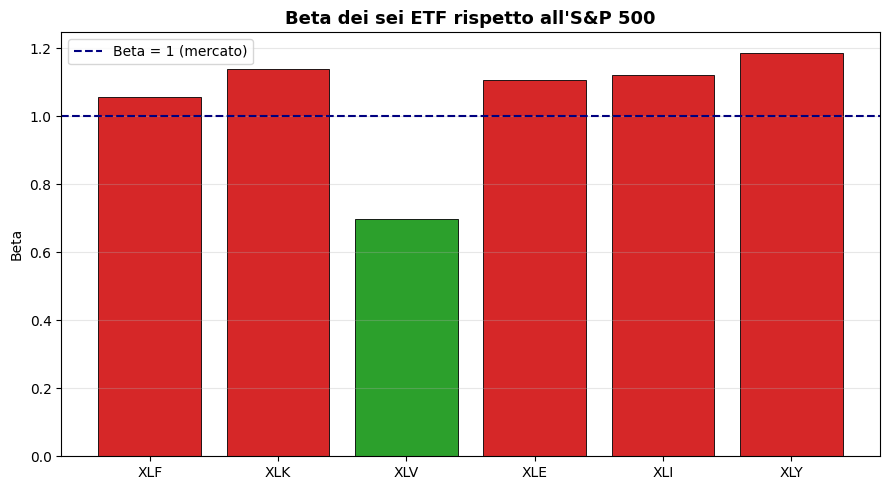

In [ ]:
## PUNTO 3a – Beta di ciascun ETF rispetto all'S&P 500

betas = {}
r_market = log_returns_monthly['SP500']

for etf in etfs:
    r_etf = log_returns_monthly[etf]
    cov   = np.cov(r_etf, r_market)[0, 1]
    var_m = np.var(r_market, ddof=1)
    betas[etf] = cov / var_m

beta_df = pd.DataFrame.from_dict(betas, orient='index', columns=['Beta'])
print("--- Beta di ciascun ETF rispetto all'S&P 500 ---")
print(beta_df.round(4))

# Grafico beta
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#d62728' if b > 1 else '#2ca02c' for b in beta_df['Beta']]
ax.bar(beta_df.index, beta_df['Beta'], color=colors, edgecolor='black', linewidth=0.6)
ax.axhline(1, color='navy', linestyle='--', label='Beta = 1 (mercato)')
ax.set_title('Beta dei sei ETF rispetto all\'S&P 500', fontsize=13, fontweight='bold')
ax.set_ylabel('Beta')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

--- Rendimento Atteso CAPM Annuo ---
       Beta  R_f (%)  E(R_m) (%)  E(R_i) CAPM (%)
ETF                                              
XLF  1.0572      4.5         8.0            8.200
XLK  1.1376      4.5         8.0            8.482
XLV  0.6984      4.5         8.0            6.944
XLE  1.1074      4.5         8.0            8.376
XLI  1.1198      4.5         8.0            8.419
XLY  1.1871      4.5         8.0            8.655


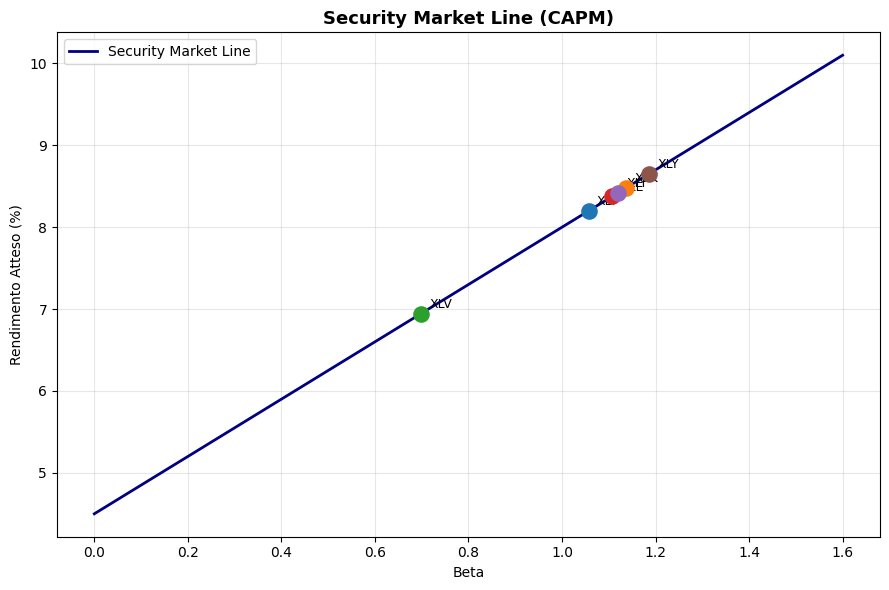

In [ ]:
## PUNTO 3b – Rendimento atteso con il CAPM

Rf_annual  = 0.045
Rm_annual  = 0.08  

capm_results = []
for etf in etfs:
    b = betas[etf]
    er = Rf_annual + b * (Rm_annual - Rf_annual)
    capm_results.append({'ETF': etf, 'Beta': round(b, 4),
                         'R_f (%)': round(Rf_annual * 100, 2),
                         'E(R_m) (%)': round(Rm_annual * 100, 2),
                         'E(R_i) CAPM (%)': round(er * 100, 3)})

capm_df = pd.DataFrame(capm_results).set_index('ETF')
print("--- Rendimento Atteso CAPM Annuo ---")
print(capm_df)

# Grafico Security Market Line (SML)
beta_range = np.linspace(0, 1.6, 100)
sml = Rf_annual + beta_range * (Rm_annual - Rf_annual)

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(beta_range, sml * 100, 'navy', lw=2, label='Security Market Line')
for etf in etfs:
    b  = betas[etf]
    er = Rf_annual + b * (Rm_annual - Rf_annual)
    ax.scatter(b, er * 100, s=120, zorder=5)
    ax.annotate(etf, (b, er * 100), textcoords='offset points', xytext=(6, 4), fontsize=9)

ax.set_xlabel('Beta')
ax.set_ylabel('Rendimento Atteso (%)')
ax.set_title('Security Market Line (CAPM)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [7]:
## PUNTO 3c – Esposizione ai fattori di rischio Fama-French (3 fattori)

import requests, zipfile, io

url = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"
response = requests.get(url, timeout=30)
response.raise_for_status()

with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    fname = [n for n in z.namelist() if n.endswith(".CSV") or n.endswith(".csv")][0]
    with z.open(fname) as f:
        raw = f.read().decode("utf-8", errors="replace")

# Il file CSV ha due sezioni (mensile e annuale); la prima termina con una riga vuota.
lines = raw.splitlines()

# Trova la riga di intestazione e la fine della sezione mensile
header_idx = next(i for i, l in enumerate(lines) if "Mkt-RF" in l)
end_idx = next((i for i, l in enumerate(lines) if i > header_idx and l.strip() == ""), len(lines))

# Parsing
from io import StringIO
ff3_raw = pd.read_csv(StringIO("\n".join(lines[header_idx:end_idx])), index_col=0)
ff3_raw.index = pd.to_datetime(ff3_raw.index.astype(str).str.strip(), format="%Y%m")
ff3_raw = ff3_raw.apply(pd.to_numeric, errors="coerce").dropna()
ff3_raw = ff3_raw / 100  # da percentuale a decimale

# Filtro sul periodo di interesse
ff3 = ff3_raw[(ff3_raw.index >= "2016-04") & (ff3_raw.index <= "2026-03")].copy()

print("Fattori Fama-French scaricati. Shape:", ff3.shape)
print(ff3.tail())

Fattori Fama-French scaricati. Shape: (120, 4)
            Mkt-RF     SMB     HML      RF
2025-11-01 -0.0013  0.0054  0.0357  0.0030
2025-12-01 -0.0036 -0.0103  0.0236  0.0034
2026-01-01  0.0103  0.0212  0.0385  0.0030
2026-02-01 -0.0117  0.0024  0.0264  0.0028
2026-03-01 -0.0518  0.0044  0.0335  0.0029


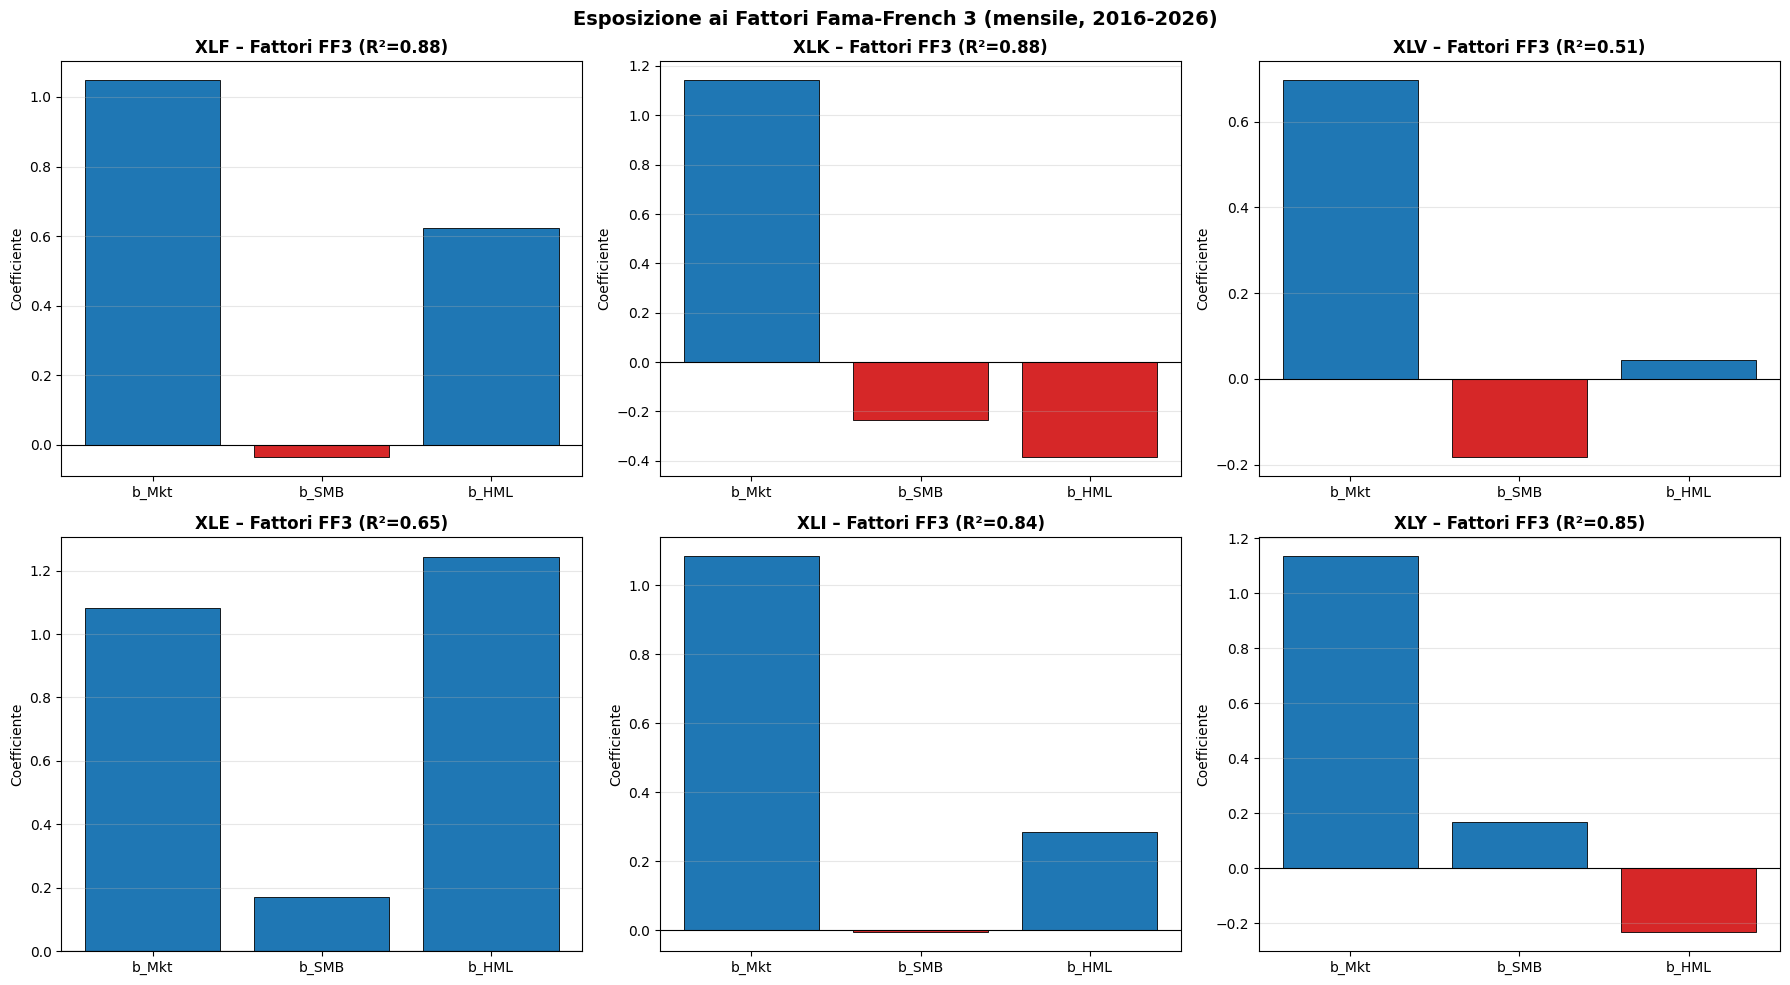


--- Risultati Regressione Fama-French 3 Fattori ---
     Alpha (ann.)   b_Mkt   b_SMB   b_HML      R²
ETF                                              
XLF       -0.0365  1.0484 -0.0339  0.6229  0.8780
XLK        0.0206  1.1424 -0.2331 -0.3838  0.8786
XLV       -0.0185  0.6967 -0.1820  0.0435  0.5134
XLE       -0.0445  1.0811  0.1722  1.2443  0.6541
XLI       -0.0347  1.0860 -0.0066  0.2851  0.8403
XLY       -0.0497  1.1371  0.1675 -0.2332  0.8527


In [ ]:
# Regressione OLS per ciascun ETF sui 3 fattori FF

import statsmodels.api as sm

# Allineamento temporale
ret_m = log_returns_monthly[etfs].copy()
ret_m.index = ret_m.index.to_period('M').to_timestamp()
ff3.index   = ff3.index.to_period('M').to_timestamp()

combined = ret_m.join(ff3, how='inner')

ff_results = []
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, etf in enumerate(etfs):
    y = combined[etf] - combined['RF']
    X = sm.add_constant(combined[['Mkt-RF', 'SMB', 'HML']])
    model = sm.OLS(y, X).fit()

    ff_results.append({
        'ETF': etf,
        'Alpha (ann.)': round(model.params['const'] * 12, 4),
        'b_Mkt': round(model.params['Mkt-RF'], 4),
        'b_SMB': round(model.params['SMB'], 4),
        'b_HML': round(model.params['HML'], 4),
        'R²': round(model.rsquared, 4)
    })

    # Grafico contributo fattori
    factors = ['b_Mkt', 'b_SMB', 'b_HML']
    vals = [model.params['Mkt-RF'], model.params['SMB'], model.params['HML']]
    bars = axes[i].bar(factors, vals,
                       color=['#1f77b4' if v >= 0 else '#d62728' for v in vals],
                       edgecolor='black', linewidth=0.6)
    axes[i].axhline(0, color='black', lw=0.8)
    axes[i].set_title(f'{etf} – Fattori FF3 (R²={model.rsquared:.2f})', fontweight='bold')
    axes[i].set_ylabel('Coefficiente')
    axes[i].grid(axis='y', alpha=0.3)

plt.suptitle('Esposizione ai Fattori Fama-French 3 (mensile, 2016-2026)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

ff_df = pd.DataFrame(ff_results).set_index('ETF')
print("\n--- Risultati Regressione Fama-French 3 Fattori ---")
print(ff_df)

---
# PUNTO 4 – Strategie di Trading e Backtesting – CPPI

In [9]:
## PUNTO 4a – Strategia CPPI: dati storici vs simulazione Montecarlo

TICKER = 'XLK'
V0  = 1000.0
F   = 800.0
m   = 3
n_giorni = 252

# --- Dati storici: ultimo anno del campione ---
r_daily = log_returns[TICKER].dropna()
r_last_year = r_daily.iloc[-n_giorni:].values

def cppi_simulation(returns, V0, F, m):
    """Esegue la strategia CPPI su una serie di rendimenti giornalieri."""
    V = V0
    values = [V]
    risky_alloc = []
    for r in returns:
        cushion = max(V - F, 0)
        E = min(m * cushion, V)   # allocazione rischiosa
        S = V - E                 # allocazione sicura (rendimento = 0 per semplicità)
        risky_alloc.append(E / V if V > 0 else 0)
        V = E * np.exp(r) + S
        V = max(V, F)             # floor garantito
        values.append(V)
    return np.array(values), np.array(risky_alloc)

values_hist, alloc_hist = cppi_simulation(r_last_year, V0, F, m)

# --- Simulazione Montecarlo ---
mu_daily  = r_daily.mean()
sig_daily = r_daily.std()
n_sim = 500
np.random.seed(42)
mc_returns = np.random.normal(mu_daily, sig_daily, (n_sim, n_giorni))

mc_final_values = []
mc_all_paths = []
for i in range(n_sim):
    vals, _ = cppi_simulation(mc_returns[i], V0, F, m)
    mc_final_values.append(vals[-1])
    mc_all_paths.append(vals)

mc_all_paths = np.array(mc_all_paths)  # shape: (n_sim, n_giorni+1)

# --- Buy & Hold storico per confronto ---
bh_values = V0 * np.exp(np.cumsum(np.insert(r_last_year, 0, 0)))

print(f"CPPI Storico – Valore finale: {values_hist[-1]:.2f}")
print(f"Buy & Hold  – Valore finale: {bh_values[-1]:.2f}")
print(f"Montecarlo  – Media valore finale: {np.mean(mc_final_values):.2f}")
print(f"Montecarlo  – Mediana valore finale: {np.median(mc_final_values):.2f}")
print(f"Montecarlo  – % simulazioni < floor: {(np.array(mc_final_values) < F).mean()*100:.1f}%")

CPPI Storico – Valore finale: 1106.93
Buy & Hold  – Valore finale: 1212.51
Montecarlo  – Media valore finale: 1171.13
Montecarlo  – Mediana valore finale: 1113.63
Montecarlo  – % simulazioni < floor: 0.0%


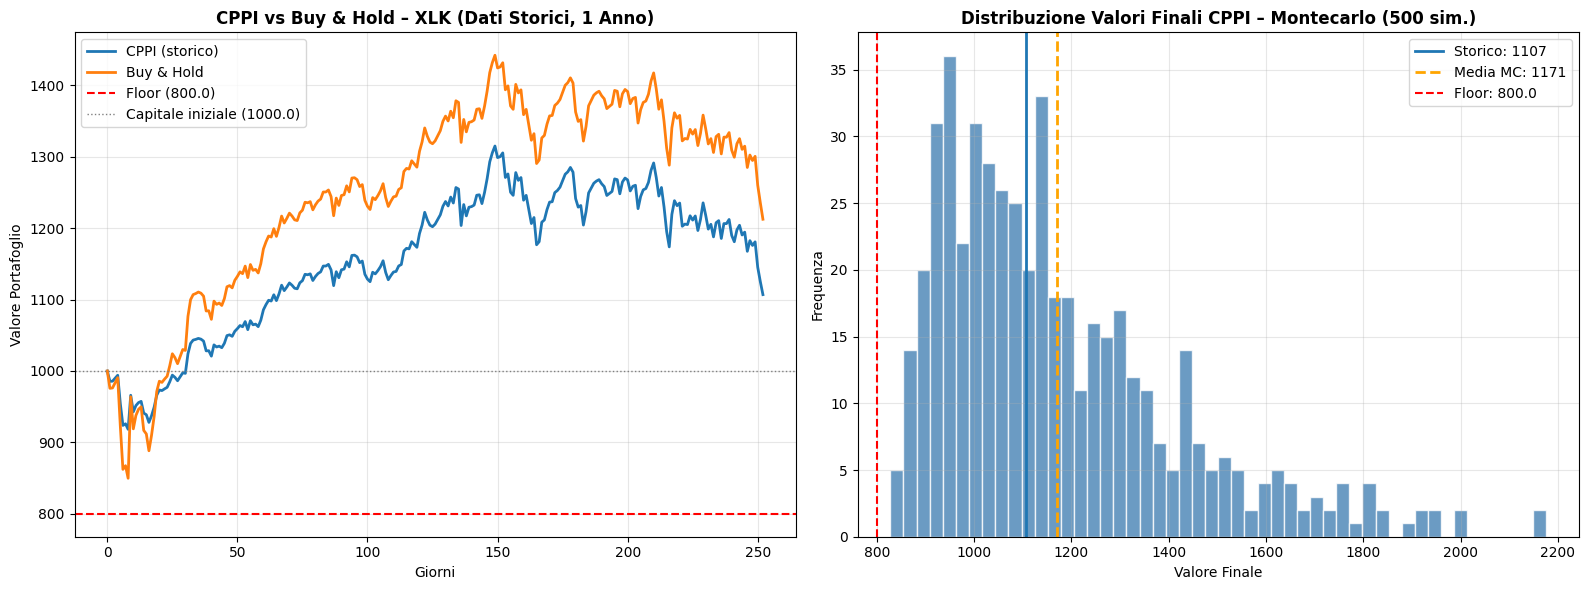

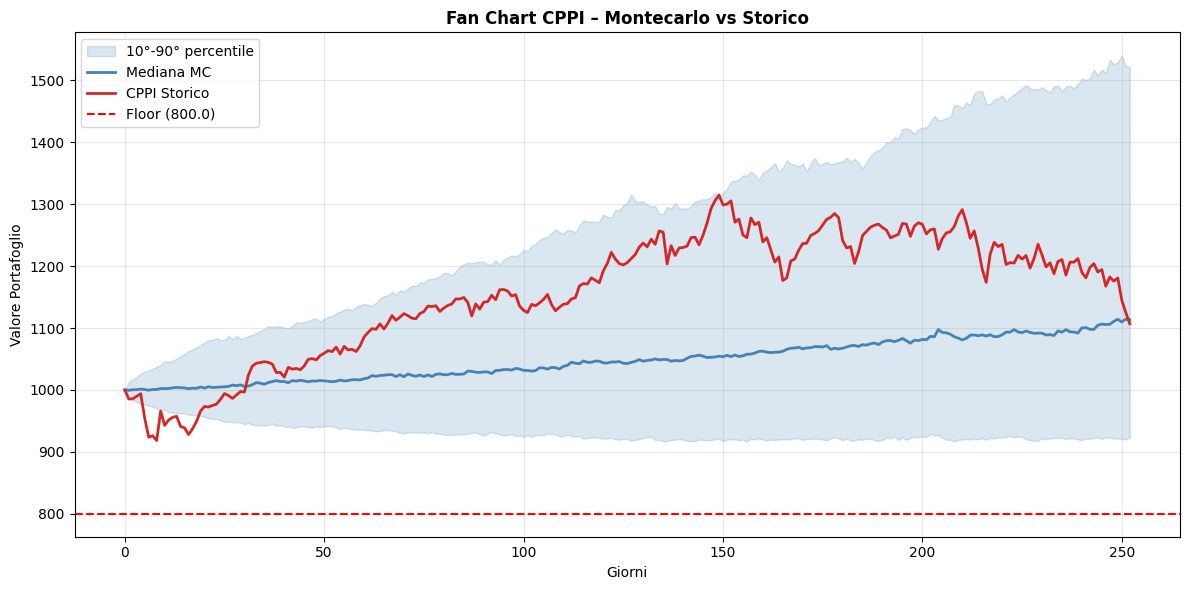

In [10]:
# Grafico 1: CPPI storico vs Buy & Hold
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(values_hist, label='CPPI (storico)', color='#1f77b4', lw=2)
axes[0].plot(bh_values,  label='Buy & Hold',    color='#ff7f0e', lw=2)
axes[0].axhline(F, color='red', linestyle='--', lw=1.5, label=f'Floor ({F})')
axes[0].axhline(V0, color='grey', linestyle=':', lw=1, label=f'Capitale iniziale ({V0})')
axes[0].set_title(f'CPPI vs Buy & Hold – {TICKER} (Dati Storici, 1 Anno)', fontweight='bold')
axes[0].set_xlabel('Giorni')
axes[0].set_ylabel('Valore Portafoglio')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Grafico 2: Distribuzione dei valori finali Montecarlo
axes[1].hist(mc_final_values, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[1].axvline(values_hist[-1], color='#1f77b4', lw=2, label=f'Storico: {values_hist[-1]:.0f}')
axes[1].axvline(np.mean(mc_final_values), color='orange', lw=2, linestyle='--',
                label=f'Media MC: {np.mean(mc_final_values):.0f}')
axes[1].axvline(F, color='red', lw=1.5, linestyle='--', label=f'Floor: {F}')
axes[1].set_title(f'Distribuzione Valori Finali CPPI – Montecarlo ({n_sim} sim.)', fontweight='bold')
axes[1].set_xlabel('Valore Finale')
axes[1].set_ylabel('Frequenza')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Grafico 3: Evoluzione percorsi Montecarlo (fan chart)
fig, ax = plt.subplots(figsize=(12, 6))
p10 = np.percentile(mc_all_paths, 10, axis=0)
p50 = np.percentile(mc_all_paths, 50, axis=0)
p90 = np.percentile(mc_all_paths, 90, axis=0)

ax.fill_between(range(n_giorni+1), p10, p90, alpha=0.2, color='steelblue', label='10°-90° percentile')
ax.plot(p50, color='steelblue', lw=2, label='Mediana MC')
ax.plot(values_hist, color='#d62728', lw=2, label='CPPI Storico')
ax.axhline(F, color='red', linestyle='--', lw=1.5, label=f'Floor ({F})')
ax.set_title('Fan Chart CPPI – Montecarlo vs Storico', fontweight='bold')
ax.set_xlabel('Giorni')
ax.set_ylabel('Valore Portafoglio')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
## PUNTO 4b – Confronto CPPI vs Buy & Hold: rendimento ed efficienza

def sharpe(values, Rf_daily=Rf_annual/252):
    """Calcola lo Sharpe Ratio da una serie di valori giornalieri."""
    rets = np.diff(values) / values[:-1]
    excess = rets - Rf_daily
    return (excess.mean() / excess.std()) * np.sqrt(252) if excess.std() > 0 else np.nan

def max_drawdown(values):
    """Calcola il massimo drawdown."""
    peak = np.maximum.accumulate(values)
    dd = (values - peak) / peak
    return dd.min()

ret_cppi = (values_hist[-1] - V0) / V0
ret_bh   = (bh_values[-1] - V0) / V0

comparison = pd.DataFrame({
    'Strategia': ['CPPI (storico)', 'Buy & Hold'],
    'Valore Finale': [round(values_hist[-1], 2), round(bh_values[-1], 2)],
    'Rendimento (%)': [round(ret_cppi * 100, 2), round(ret_bh * 100, 2)],
    'Sharpe Ratio':   [round(sharpe(values_hist), 3), round(sharpe(bh_values), 3)],
    'Max Drawdown (%)': [round(max_drawdown(values_hist) * 100, 2), round(max_drawdown(bh_values) * 100, 2)]
}).set_index('Strategia')

print("--- Confronto CPPI vs Buy & Hold ---")
print(comparison)

--- Confronto CPPI vs Buy & Hold ---
                Valore Finale  Rendimento (%)  Sharpe Ratio  Max Drawdown (%)
Strategia                                                                    
CPPI (storico)        1106.93           10.69         0.387            -15.82
Buy & Hold            1212.51           21.25         0.684            -15.92


--- Sensitività al Moltiplicatore m ---
   Valore Finale  Rendimento (%)  Sharpe  Max DD (%)
m                                                   
1        1042.50            4.25  -0.030       -4.22
2        1074.27            7.43   0.276      -10.19
3        1106.93           10.69   0.387      -15.82
4        1137.07           13.71   0.501      -15.92
5        1128.60           12.86   0.456      -15.92
6        1128.65           12.86   0.449      -15.92

--- Sensitività al Floor F ---
           Valore Finale  Rendimento (%)  Sharpe  Max DD (%)
Floor (%)                                                   
70               1165.51           16.55   0.586      -15.92
75               1145.92           14.59   0.534      -15.92
80               1106.93           10.69   0.387      -15.82
85               1067.15            6.72   0.207      -13.88
90               1044.77            4.48   0.042       -9.89


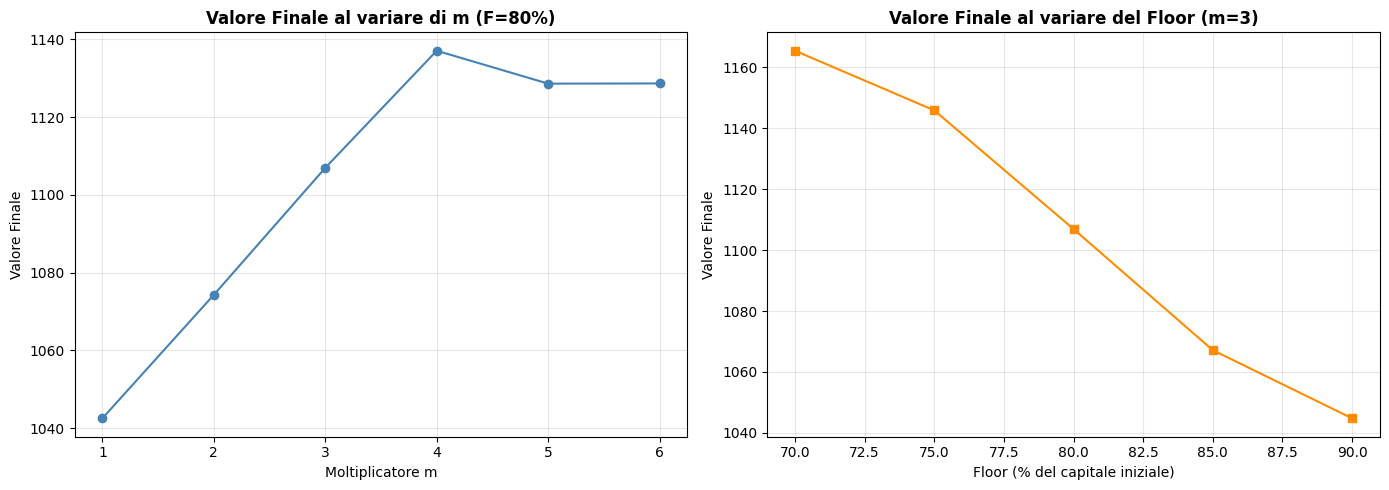

In [12]:
## PUNTO 4c – Analisi di sensitività ai parametri CPPI

mult_range  = [1, 2, 3, 4, 5, 6]
floor_range = [0.70, 0.75, 0.80, 0.85, 0.90]

# Sensitività al moltiplicatore (floor fisso = 0.80 * V0)
sensitivity_m = []
for m_val in mult_range:
    vals, _ = cppi_simulation(r_last_year, V0, V0 * 0.80, m_val)
    sensitivity_m.append({'m': m_val,
                           'Valore Finale': round(vals[-1], 2),
                           'Rendimento (%)': round((vals[-1] - V0) / V0 * 100, 2),
                           'Sharpe': round(sharpe(vals), 3),
                           'Max DD (%)': round(max_drawdown(vals) * 100, 2)})

# Sensitività al floor (m fisso = 3)
sensitivity_f = []
for f_pct in floor_range:
    vals, _ = cppi_simulation(r_last_year, V0, V0 * f_pct, 3)
    sensitivity_f.append({'Floor (%)': int(f_pct * 100),
                           'Valore Finale': round(vals[-1], 2),
                           'Rendimento (%)': round((vals[-1] - V0) / V0 * 100, 2),
                           'Sharpe': round(sharpe(vals), 3),
                           'Max DD (%)': round(max_drawdown(vals) * 100, 2)})

sens_m_df = pd.DataFrame(sensitivity_m).set_index('m')
sens_f_df = pd.DataFrame(sensitivity_f).set_index('Floor (%)')

print("--- Sensitività al Moltiplicatore m ---")
print(sens_m_df)
print("\n--- Sensitività al Floor F ---")
print(sens_f_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(sens_m_df.index, sens_m_df['Valore Finale'], 'o-', color='steelblue')
axes[0].set_title('Valore Finale al variare di m (F=80%)', fontweight='bold')
axes[0].set_xlabel('Moltiplicatore m'); axes[0].set_ylabel('Valore Finale'); axes[0].grid(alpha=0.3)

axes[1].plot(sens_f_df.index, sens_f_df['Valore Finale'], 's-', color='darkorange')
axes[1].set_title('Valore Finale al variare del Floor (m=3)', fontweight='bold')
axes[1].set_xlabel('Floor (% del capitale iniziale)'); axes[1].set_ylabel('Valore Finale'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
# PUNTO 5 – Costruzione di Portafoglio Ottimale

In [ ]:
## PUNTO 5a – Portafoglio ottimale media-varianza (Training set: primi 108 mesi)

ret_m_etfs = log_returns_monthly[etfs].copy()
train = ret_m_etfs.iloc[:108]

# Rendimenti e matrice covarianza (annualizzati)
mu_hist = train.mean() * 12          # rendimenti storici annualizzati
mu_capm = capm_df['E(R_i) CAPM (%)'] / 100   # rendimenti CAPM
cov_m   = train.cov() * 12           # covarianza annualizzata
n = len(etfs)

print("Training set: mesi disponibili:", len(train))
print("\nRendimenti annui storici (%):\n", (mu_hist * 100).round(2))
print("\nRendimenti attesi CAPM (%):\n", (mu_capm * 100).round(2))

Training set: mesi disponibili: 108

Rendimenti annui storici (%):
 Ticker
XLF    13.05
XLK    18.23
XLV    10.19
XLE     8.73
XLI    11.35
XLY    11.25
dtype: float64

Rendimenti attesi CAPM (%):
 ETF
XLF    8.20
XLK    8.48
XLV    6.94
XLE    8.38
XLI    8.42
XLY    8.65
Name: E(R_i) CAPM (%), dtype: float64


In [14]:
# Funzioni di ottimizzazione

def portfolio_performance(w, mu, cov):
    ret = np.dot(w, mu)
    vol = np.sqrt(w @ cov @ w)
    return ret, vol

def neg_sharpe(w, mu, cov, Rf=Rf_annual):
    r, v = portfolio_performance(w, mu, cov)
    return -(r - Rf) / v

def min_variance(w, cov):
    return w @ cov @ w

constraints = [{'type': 'eq', 'fun': lambda w: np.sum(w) - 1}]
bounds = tuple((0, 1) for _ in range(n))   # no short selling

# --- Ottimizzazione con rendimenti storici ---
res_sharpe_hist = minimize(neg_sharpe, x0=np.ones(n)/n,
                           args=(mu_hist.values, cov_m.values),
                           method='SLSQP', bounds=bounds, constraints=constraints)
w_sharpe_hist = res_sharpe_hist.x

res_minvar = minimize(min_variance, x0=np.ones(n)/n,
                      args=(cov_m.values,),
                      method='SLSQP', bounds=bounds, constraints=constraints)
w_minvar = res_minvar.x

# --- Ottimizzazione con rendimenti CAPM ---
mu_capm_arr = mu_capm.values
res_sharpe_capm = minimize(neg_sharpe, x0=np.ones(n)/n,
                           args=(mu_capm_arr, cov_m.values),
                           method='SLSQP', bounds=bounds, constraints=constraints)
w_sharpe_capm = res_sharpe_capm.x

# Stampa risultati
for label, w, mu_use in [('Max Sharpe (storici)', w_sharpe_hist, mu_hist.values),
                          ('Min Varianza',         w_minvar,       mu_hist.values),
                          ('Max Sharpe (CAPM)',    w_sharpe_capm,  mu_capm_arr)]:
    r, v = portfolio_performance(w, mu_use, cov_m.values)
    sr   = (r - Rf_annual) / v
    print(f"\n--- {label} ---")
    for etf, wi in zip(etfs, w):
        print(f"  {etf}: {wi*100:.2f}%")
    print(f"  Rendimento: {r*100:.2f}%  |  Volatilità: {v*100:.2f}%  |  Sharpe: {sr:.3f}")


--- Max Sharpe (storici) ---
  XLF: 0.00%
  XLK: 100.00%
  XLV: 0.00%
  XLE: 0.00%
  XLI: 0.00%
  XLY: 0.00%
  Rendimento: 18.23%  |  Volatilità: 19.31%  |  Sharpe: 0.711

--- Min Varianza ---
  XLF: 3.67%
  XLK: 13.69%
  XLV: 82.63%
  XLE: 0.00%
  XLI: 0.00%
  XLY: 0.00%
  Rendimento: 11.39%  |  Volatilità: 13.93%  |  Sharpe: 0.495

--- Max Sharpe (CAPM) ---
  XLF: 11.40%
  XLK: 37.74%
  XLV: 17.51%
  XLE: 0.00%
  XLI: 21.66%
  XLY: 11.70%
  Rendimento: 8.19%  |  Volatilità: 16.46%  |  Sharpe: 0.224


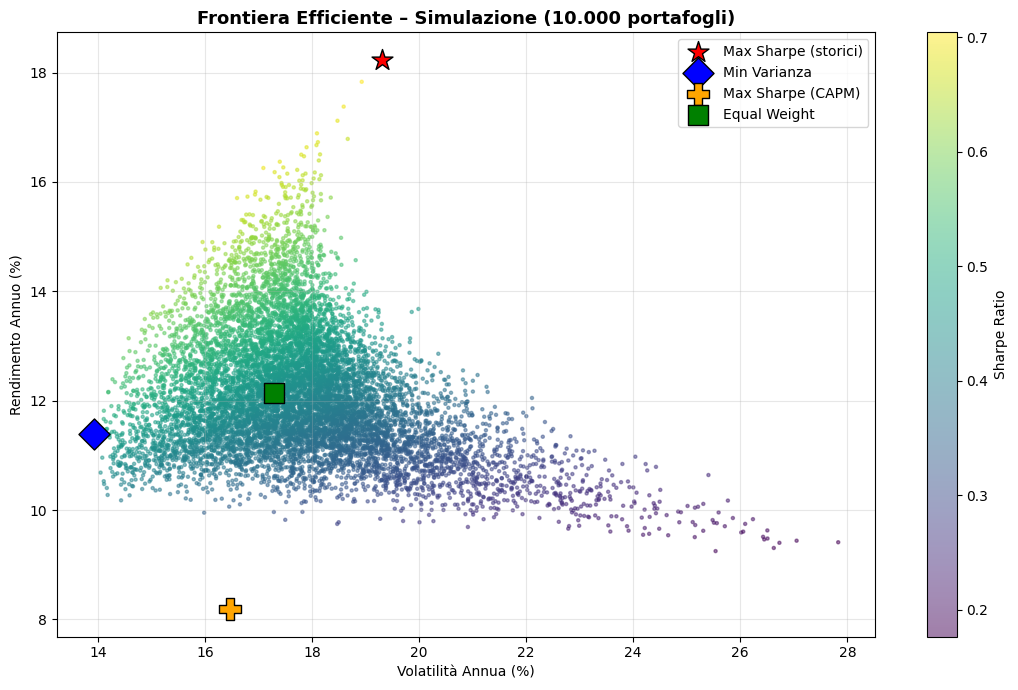

In [15]:
# Frontiera efficiente – Metodo simulazione (10.000 portafogli casuali)
np.random.seed(0)
N_SIM = 10000
sim_ret, sim_vol, sim_sr = [], [], []

for _ in range(N_SIM):
    w = np.random.dirichlet(np.ones(n))  # pesi sommano a 1, tutti positivi
    r, v = portfolio_performance(w, mu_hist.values, cov_m.values)
    sim_ret.append(r)
    sim_vol.append(v)
    sim_sr.append((r - Rf_annual) / v)

sim_ret = np.array(sim_ret)
sim_vol = np.array(sim_vol)
sim_sr  = np.array(sim_sr)

fig, ax = plt.subplots(figsize=(11, 7))
scatter = ax.scatter(sim_vol * 100, sim_ret * 100, c=sim_sr, cmap='viridis', s=5, alpha=0.5)
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')

# Portafogli ottimali
for label, w, mu_use, marker, col in [
    ('Max Sharpe (storici)', w_sharpe_hist, mu_hist.values, '*', 'red'),
    ('Min Varianza',         w_minvar,       mu_hist.values, 'D', 'blue'),
    ('Max Sharpe (CAPM)',    w_sharpe_capm,  mu_capm_arr,   'P', 'orange')]:
    r, v = portfolio_performance(w, mu_use, cov_m.values)
    ax.scatter(v * 100, r * 100, s=250, c=col, marker=marker, zorder=10, label=label, edgecolors='black')

# Equal Weight
w_ew = np.ones(n) / n
r_ew, v_ew = portfolio_performance(w_ew, mu_hist.values, cov_m.values)
ax.scatter(v_ew * 100, r_ew * 100, s=200, c='green', marker='s', zorder=10, label='Equal Weight', edgecolors='black')

ax.set_xlabel('Volatilità Annua (%)')
ax.set_ylabel('Rendimento Annuo (%)')
ax.set_title('Frontiera Efficiente – Simulazione (10.000 portafogli)', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
## PUNTO 5b – Beta del portafoglio ottimale rispetto al mercato

beta_arr = np.array([betas[etf] for etf in etfs])

for label, w in [('Max Sharpe (storici)', w_sharpe_hist),
                  ('Min Varianza',         w_minvar),
                  ('Max Sharpe (CAPM)',    w_sharpe_capm),
                  ('Equal Weight',         w_ew)]:
    bp = np.dot(w, beta_arr)
    print(f"{label:30s}  Beta portafoglio = {bp:.4f}")

Max Sharpe (storici)            Beta portafoglio = 1.1376
Min Varianza                    Beta portafoglio = 0.7717
Max Sharpe (CAPM)               Beta portafoglio = 1.0535
Equal Weight                    Beta portafoglio = 1.0512


Test set: 12 mesi (da 2025-04 a 2026-03)


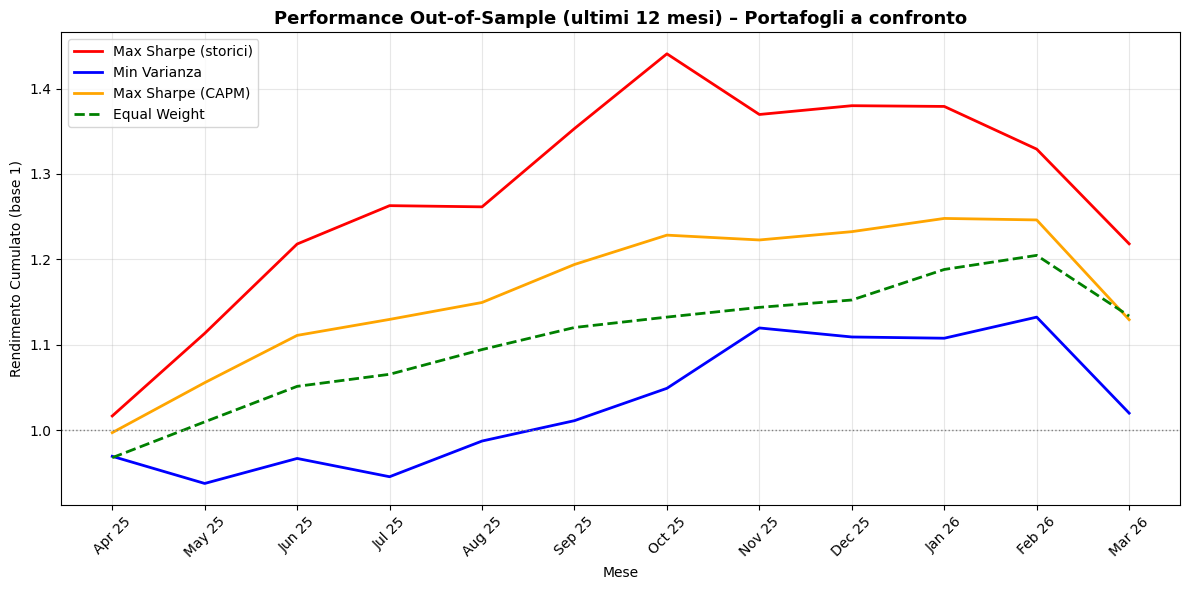


--- Tabella Riassuntiva Out-of-Sample ---
                      Rend. OOS (%)  Vol. OOS (%)  Sharpe OOS  Beta ptf
Portafoglio                                                            
Max Sharpe (storici)          21.82         19.76       0.869     1.138
Min Varianza                   2.01         15.59      -0.088     0.772
Max Sharpe (CAPM)             12.94         13.50       0.637     1.053
Equal Weight                  13.37         10.20       0.843     1.051


In [17]:
## PUNTO 5c – Confronto portafoglio ottimale vs portafoglio Equal Weight (effettivo)

test = ret_m_etfs.iloc[108:]   # ultimi 12 mesi (o quanti disponibili)
print(f"Test set: {len(test)} mesi (da {test.index[0].strftime('%Y-%m')} a {test.index[-1].strftime('%Y-%m')})")

# Valore cumulato dei portafogli nel periodo di test
cum_sharpe_hist = (1 + test[etfs].dot(w_sharpe_hist)).cumprod()
cum_minvar      = (1 + test[etfs].dot(w_minvar)).cumprod()
cum_sharpe_capm = (1 + test[etfs].dot(w_sharpe_capm)).cumprod()
cum_ew          = (1 + test[etfs].dot(w_ew)).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(cum_sharpe_hist.values, label='Max Sharpe (storici)', color='red',    lw=2)
ax.plot(cum_minvar.values,      label='Min Varianza',          color='blue',   lw=2)
ax.plot(cum_sharpe_capm.values, label='Max Sharpe (CAPM)',     color='orange', lw=2)
ax.plot(cum_ew.values,          label='Equal Weight',           color='green',  lw=2, linestyle='--')
ax.axhline(1, color='grey', linestyle=':', lw=1)
ax.set_title('Performance Out-of-Sample (ultimi 12 mesi) – Portafogli a confronto', fontsize=13, fontweight='bold')
ax.set_xlabel('Mese')
ax.set_ylabel('Rendimento Cumulato (base 1)')
ax.set_xticks(range(len(test)))
ax.set_xticklabels([d.strftime('%b %y') for d in test.index], rotation=45)
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Tabella riassuntiva
portfolios_test = {
    'Max Sharpe (storici)': (cum_sharpe_hist, w_sharpe_hist, mu_hist.values),
    'Min Varianza':          (cum_minvar,      w_minvar,       mu_hist.values),
    'Max Sharpe (CAPM)':    (cum_sharpe_capm, w_sharpe_capm,  mu_capm_arr),
    'Equal Weight':          (cum_ew,          w_ew,           mu_hist.values),
}

summary = []
for label, (cum, w, mu_use) in portfolios_test.items():
    ret_oos  = cum.iloc[-1] - 1
    monthly_rets = test[etfs].dot(w)
    vol_oos  = monthly_rets.std() * np.sqrt(12)
    sr_oos   = (monthly_rets.mean() * 12 - Rf_annual) / vol_oos if vol_oos > 0 else np.nan
    bp       = np.dot(w, beta_arr)
    summary.append({'Portafoglio': label,
                    'Rend. OOS (%)': round(ret_oos * 100, 2),
                    'Vol. OOS (%)':  round(vol_oos * 100, 2),
                    'Sharpe OOS':    round(sr_oos, 3),
                    'Beta ptf':      round(bp, 3)})

summary_df = pd.DataFrame(summary).set_index('Portafoglio')
print("\n--- Tabella Riassuntiva Out-of-Sample ---")
print(summary_df)